In [1]:
import os
import numpy as np
import scipy.io as sio
from tqdm import tqdm
import h5py

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

import sys
sys.path.append("..") 

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [2]:
import random

SEED = 100

# Python random
random.seed(SEED)

# NumPy
np.random.seed(SEED)

# PyTorch CPU
torch.manual_seed(SEED)

# PyTorch GPU
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Make CUDA operations deterministic
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
from UCI.pre_processing import extract_bp_from_abp, process_recording, process_split, load_UCI_dataset, create_dataloaders

In [4]:
X_train, y_train, X_val, y_val, X_test, y_test = load_UCI_dataset(WINDOW_SIZE= 1000, STEP_SIZE= 500)

Total recordings: 12000
Train recordings: 8640
Validation recordings: 960
Test recordings: 2400


100%|██████████| 8640/8640 [02:42<00:00, 53.09it/s] 


Skipped recordings: 4


100%|██████████| 960/960 [00:17<00:00, 53.55it/s]


Skipped recordings: 0


100%|██████████| 2400/2400 [00:43<00:00, 55.48it/s]


Skipped recordings: 1


In [5]:
X_train = torch.tensor(X_train,dtype=torch.float32)
X_val = torch.tensor(X_val,dtype=torch.float32)
X_test = torch.tensor(X_test,dtype=torch.float32)

y_train = torch.tensor(y_train,dtype=torch.float32)
y_val = torch.tensor(y_val,dtype=torch.float32)
y_test = torch.tensor(y_test,dtype=torch.float32)

/tmp/ipykernel_3231761/1851050337.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train = torch.tensor(X_train,dtype=torch.float32)
/tmp/ipykernel_3231761/1851050337.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_val = torch.tensor(X_val,dtype=torch.float32)
/tmp/ipykernel_3231761/1851050337.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.tensor(X_test,dtype=torch.float32)
/tmp/ipykernel_3231761/1851050337.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clo

In [6]:
train_loader, val_loader, test_loader = create_dataloaders(X_train, y_train, X_val, y_val, X_test, y_test)

In [7]:
from models.CNN1D import CNN1D
from models.CNN_LSTM import CNN_LSTM_NoDropout

model = CNN_LSTM_NoDropout().to(device)

criterion = torch.nn.MSELoss()
# criterion = nn.SmoothL1Loss()


optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [8]:
from models.train import train_model
model, history, train_losses, val_losses = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=50
)

Epoch 1/50 | Train MSE: 2125.54 (SBP RMSE: 40.83, DBP RMSE: 21.41) | Val MSE: 513.01 (SBP RMSE: 20.00, DBP RMSE: 10.63) | Improved
Epoch 2/50 | Train MSE: 463.33 (SBP RMSE: 18.77, DBP RMSE: 10.54) | Val MSE: 461.50 (SBP RMSE: 19.01, DBP RMSE: 10.00) | Improved
Epoch 3/50 | Train MSE: 411.06 (SBP RMSE: 17.57, DBP RMSE: 10.11) | Val MSE: 461.95 (SBP RMSE: 19.17, DBP RMSE: 9.72) | No improvement (1/10)
Epoch 4/50 | Train MSE: 378.08 (SBP RMSE: 16.89, DBP RMSE: 9.64) | Val MSE: 417.64 (SBP RMSE: 18.11, DBP RMSE: 9.46) | Improved
Epoch 5/50 | Train MSE: 349.88 (SBP RMSE: 16.23, DBP RMSE: 9.30) | Val MSE: 402.17 (SBP RMSE: 17.81, DBP RMSE: 9.23) | Improved
Epoch 6/50 | Train MSE: 329.63 (SBP RMSE: 15.72, DBP RMSE: 9.09) | Val MSE: 413.68 (SBP RMSE: 18.02, DBP RMSE: 9.43) | No improvement (1/10)
Epoch 7/50 | Train MSE: 312.66 (SBP RMSE: 15.25, DBP RMSE: 8.94) | Val MSE: 394.53 (SBP RMSE: 17.59, DBP RMSE: 9.22) | Improved
Epoch 8/50 | Train MSE: 298.42 (SBP RMSE: 14.85, DBP RMSE: 8.82) | Val M

## OBSERVATION ##

- Validation error is very very high than training -> The model is clearly overfitting (starts around 8-9 epoch)

- We'll try regularization and if it doesn't work we'll reduce CNN layers

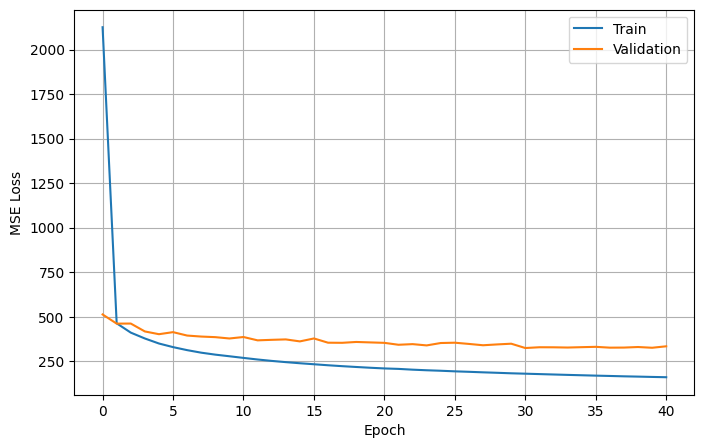

In [9]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))

plt.plot(train_losses,label="Train")
plt.plot(val_losses,label="Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid()

plt.show()

In [10]:
from models.train import evaluate_model
predictions, targets, metrics = evaluate_model(
    model,
    test_loader,
    device
)

SBP MAE: 11.07 mmHg
DBP MAE: 6.04 mmHg
SBP RMSE: 15.79 mmHg
DBP RMSE: 8.94 mmHg


Added dropout and weight decay to the model

In [11]:
from models.CNN1D import CNN1D
from models.CNN_LSTM import CNN_LSTM_Dropout

model = CNN_LSTM_Dropout().to(device)

criterion = torch.nn.MSELoss()
# criterion = nn.SmoothL1Loss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [ ]:
from models.train import train_model
model, history, train_losses, val_losses = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=50
)

Epoch 1/50 | Train MSE: 2492.89 (SBP RMSE: 44.46, DBP RMSE: 22.72) | Val MSE: 654.51 (SBP RMSE: 23.03, DBP RMSE: 11.14) | Improved
Epoch 2/50 | Train MSE: 1177.17 (SBP RMSE: 30.36, DBP RMSE: 15.98) | Val MSE: 557.69 (SBP RMSE: 21.03, DBP RMSE: 10.75) | Improved
Epoch 3/50 | Train MSE: 1086.12 (SBP RMSE: 29.10, DBP RMSE: 15.48) | Val MSE: 521.92 (SBP RMSE: 20.42, DBP RMSE: 10.25) | Improved
Epoch 4/50 | Train MSE: 1022.31 (SBP RMSE: 28.17, DBP RMSE: 15.13) | Val MSE: 598.56 (SBP RMSE: 21.94, DBP RMSE: 10.83) | No improvement (1/10)
Epoch 5/50 | Train MSE: 982.84 (SBP RMSE: 27.60, DBP RMSE: 14.87) | Val MSE: 526.73 (SBP RMSE: 20.50, DBP RMSE: 10.32) | No improvement (2/10)
Epoch 6/50 | Train MSE: 941.26 (SBP RMSE: 26.99, DBP RMSE: 14.59) | Val MSE: 491.76 (SBP RMSE: 19.66, DBP RMSE: 10.26) | Improved
Epoch 7/50 | Train MSE: 896.53 (SBP RMSE: 26.31, DBP RMSE: 14.29) | Val MSE: 466.18 (SBP RMSE: 19.10, DBP RMSE: 10.06) | Improved
Epoch 8/50 | Train MSE: 871.57 (SBP RMSE: 25.92, DBP RMSE: 1

**Still overfitting**

-Trying to normalise target and then check

In [ ]:
model = CNN_LSTM_Dropout().to(device)

criterion = torch.nn.MSELoss()
# criterion = nn.SmoothL1Loss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [ ]:
# Mean and standard deviation of BP targets

y_mean = y_train.mean(axis=0)

y_std = y_train.std(axis=0)


print("SBP mean:", y_mean[0])
print("SBP std :", y_std[0])

print("DBP mean:", y_mean[1])
print("DBP std :", y_std[1])

In [ ]:
y_train_norm = (
    y_train - y_mean
) / y_std


y_val_norm = (
    y_val - y_mean
) / y_std


y_test_norm = (
    y_test - y_mean
) / y_std

In [ ]:
y_train_tensor_norm = torch.tensor(y_train_norm, dtype=torch.float32)
y_val_tensor_norm = torch.tensor(y_val_norm, dtype=torch.float32)
y_test_tensor_norm = torch.tensor(y_test_norm, dtype=torch.float32)

In [ ]:
train_loader, val_loader, test_loader = create_dataloaders(X_train, y_train_norm, X_val, y_val_norm, X_test, y_test_norm)

In [ ]:
model, history, train_losses, val_losses = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=50
)

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(train_losses,label="Train")
plt.plot(val_losses,label="Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid()

plt.show()

In [ ]:
predictions, targets, metrics = evaluate_model(
    model,
    test_loader,
    device
)

## Reducing the size of the CNN ## 
(as the model is still overfitting)

- The targets are not normalized 


In [ ]:
class CNN_LSTM_small(nn.Module):

    def __init__(self):

        super().__init__()


        # CNN Feature Extractor (smaller)

        self.features = nn.Sequential(

            nn.Conv1d(
                in_channels=1,
                out_channels=16,
                kernel_size=5,
                padding=2
            ),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2),


            nn.Conv1d(
                in_channels=16,
                out_channels=32,
                kernel_size=5,
                padding=2
            ),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),


            nn.Conv1d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm1d(64),
            nn.ReLU()

        )


        # LSTM

        self.lstm = nn.LSTM(

            input_size=64,   # changed from 128

            hidden_size=64,

            num_layers=2,

            batch_first=True,

            dropout=0.3

        )


        # Regression Head

        self.regressor = nn.Sequential(

            nn.Linear(64,64),

            nn.ReLU(),

            nn.Dropout(0.4),

            nn.Linear(64,32),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(32,2)

        )


    def forward(self,x):

        # CNN
        x = self.features(x)

        # (batch, channels, sequence)
        # Convert for LSTM

        x = x.permute(0,2,1)

        # (batch, sequence, features)

        output, (hidden, cell) = self.lstm(x)


        # Last hidden state

        x = hidden[-1]


        x = self.regressor(x)

        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN_LSTM_small().to(device)
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [ ]:
model, history, train_losses, val_losses = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=50
)

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(train_losses,label="Train")
plt.plot(val_losses,label="Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid()

plt.show()

In [ ]:
predictions, targets, metrics = evaluate_model(
    model,
    test_loader,
    device
)